In [ ]:
# 处理 multimodal-spectroscopic-dataset 数据集
"""
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   smiles                   3235 non-null   object
 1   hsqc_nmr_peaks           3235 non-null   object
 2   hsqc_nmr_spectrum        3235 non-null   object
 3   h_nmr_peaks              3235 non-null   object
 4   h_nmr_spectra            3235 non-null   object
 5   molecular_formula        3235 non-null   object
 6   c_nmr_peaks              3235 non-null   object
 7   ir_spectra               3235 non-null   object
 8   msms_positive_10ev       3235 non-null   object
 9   msms_positive_20ev       3235 non-null   object
 10  msms_positive_40ev       3235 non-null   object
 11  msms_fragments_positive  3235 non-null   object
 12  msms_negative_10ev       3235 non-null   object
 13  msms_negative_20ev       3235 non-null   object
 14  msms_negative_40ev       3235 non-null   object
 15  msms_fragments_negative  3235 non-null   object
 16  c_nmr_spectra            3235 non-null   object
dtypes: object(17)
"""

#functions
import numpy as np
from scipy.signal import find_peaks, peak_widths
import matplotlib.pyplot as plt

data_path="xxxxx"   #TODO: Your DATA PATH
file_path = data_path+"multimodal_spectroscopic_dataset/aligned_chunk_99.parquet"

output_path = '../data/raw_data/multimodal-spectroscopic-dataset/'

In [ ]:
#functions
def extract_peaks_info_width(x, y, height=None, prominence=None, distance=None, width_rel_height=0.5, plot=False,title="Detected Peaks",xl="x",yl="y"):
    x = np.array(x)
    y = np.array(y)

    peaks, properties = find_peaks(y, height=height, prominence=prominence, distance=distance)

    widths_result = peak_widths(y, peaks, rel_height=width_rel_height)

    widths = widths_result[0]  # 宽度（单位为索引差）
    left_ips = widths_result[2]  # 左索引
    right_ips = widths_result[3]  # 右索引
    peaks_info = []
    for i, peak in enumerate(peaks):
        peak_pos = x[peak]
        peak_intensity = y[peak]

        # 将索引宽度转换为x轴实际宽度
        left = np.interp(left_ips[i], np.arange(len(x)), x)
        right = np.interp(right_ips[i], np.arange(len(x)), x)
        width = right - left

        peaks_info.append({
            "position": float(peak_pos),
            "intensity": float(peak_intensity),
            "width": float(width)
        })
    if plot:
        plt.figure(figsize=(18, 10))
        plt.plot(x, y, label="Signal")
        plt.plot(x[peaks], y[peaks], "ro", label="Peaks")
        for i in range(len(peaks)):
            left = np.interp(left_ips[i], np.arange(len(x)), x)
            right = np.interp(right_ips[i], np.arange(len(x)), x)
            plt.hlines(widths_result[1][i], left, right, color='gray', linestyle='--',linewidth=0.1, alpha=0.5)
        plt.title(title)
        plt.xlabel(xl)
        plt.ylabel(yl)
        plt.legend()
        plt.tight_layout()
        plt.show()
    return peaks_info


In [ ]:
# -- c_nmr

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import json

df = pd.read_parquet(file_path, columns=["smiles", "c_nmr_spectra"])       # "c_nmr_peaks", 

fout = open(output_path+'cnr_peaks.jsonl','w')
for idx, row in df.iterrows():
    row = df.iloc[idx]    
    spectrum_data = row["c_nmr_spectra"]
    smiles = row["smiles"]    
    if not isinstance(spectrum_data, np.ndarray):
        spectrum_data_new = np.array(spectrum_data) 
        spectrum_data = spectrum_data_new
    if np.all(spectrum_data == 0):
        continue    
    n_points = len(spectrum_data)
    ppm_axis = np.linspace(220, 0, n_points) 
    spectrum_data_new = spectrum_data/np.max(spectrum_data)
    spectrum_data = spectrum_data_new
    threshold = np.max(spectrum_data) * 0.01  # 1% 作为背景噪声过滤
    signal_indices = np.where(spectrum_data > threshold)[0]
    peaks_info=extract_peaks_info_width(ppm_axis,spectrum_data,plot=False,title=f"C NMR Spectrum (Index={idx})",xl="Chemical Shift (ppm)",yl="Intensity")
    fout.write(json.dumps({'smiles':smiles,'peaks':peaks_info,'idx':str(idx)})+'\n')
fout.close()

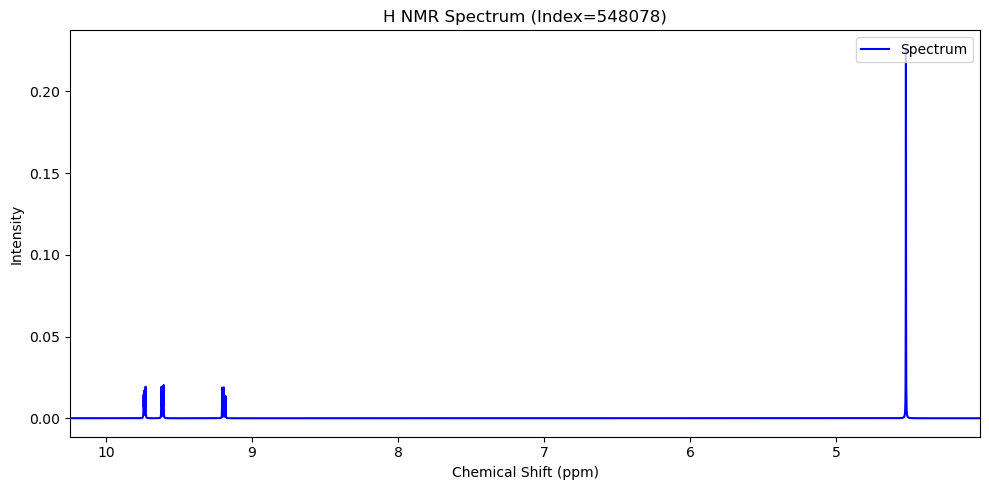

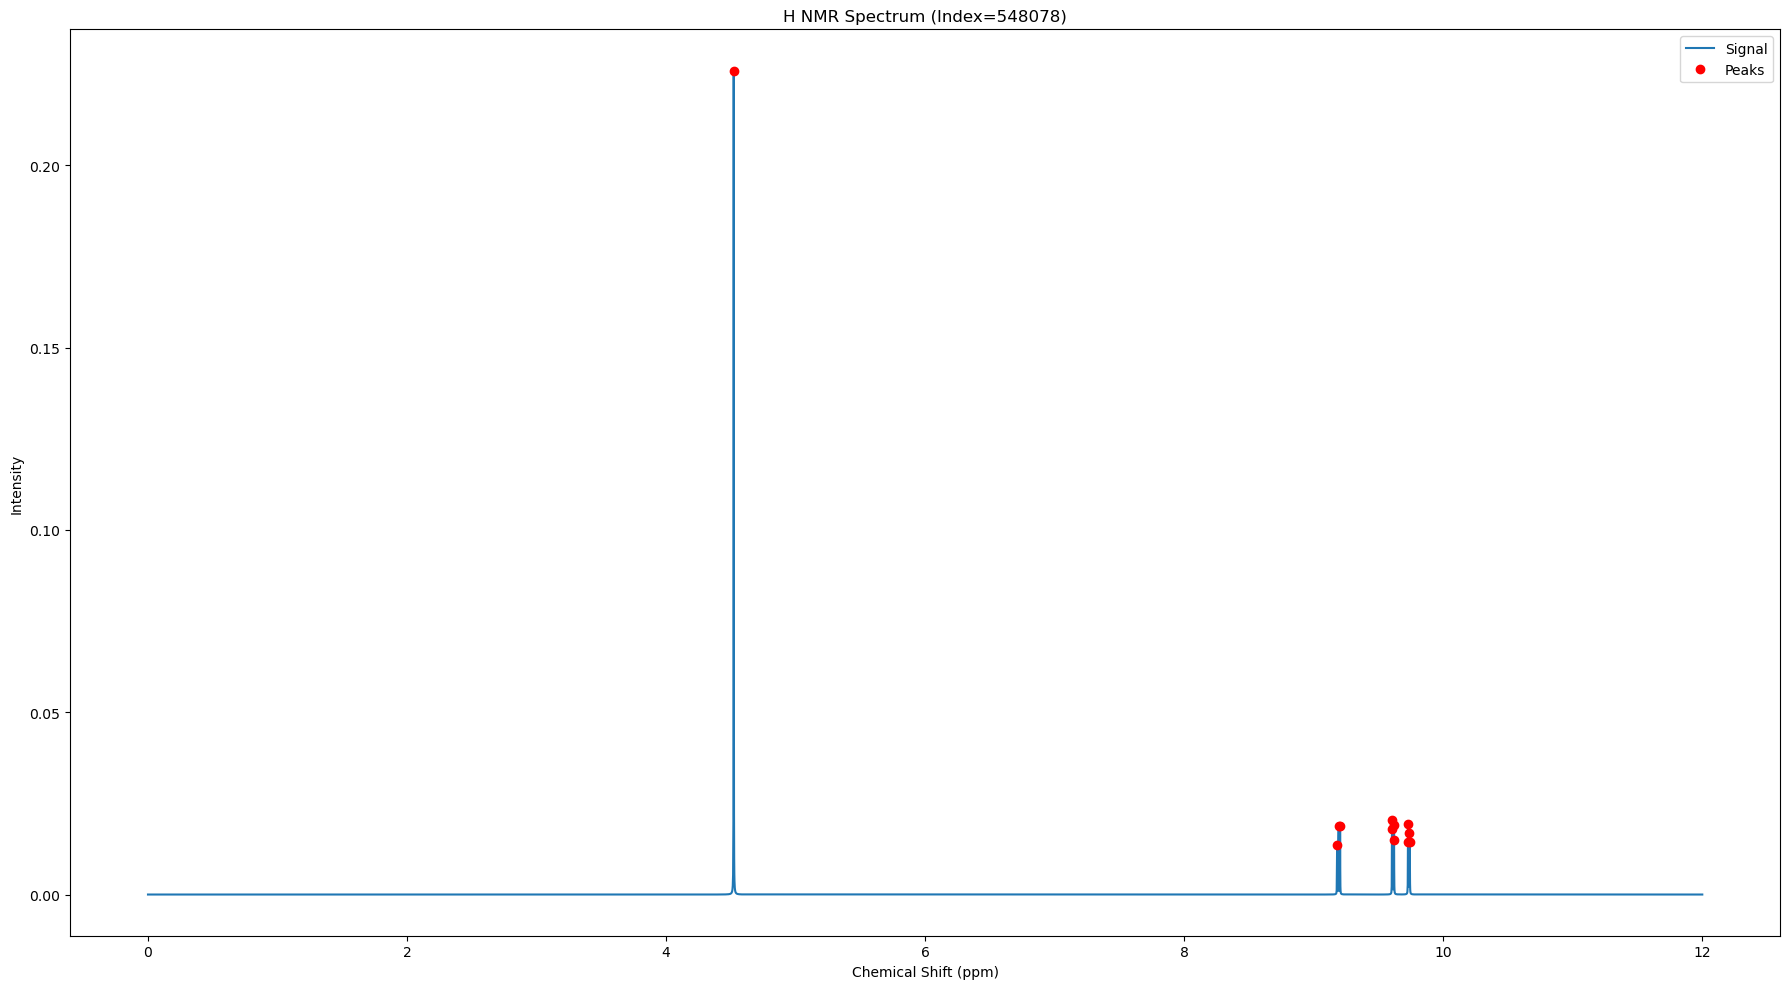

In [ ]:
# -- 绘制 h_nmr 谱图

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
        
import json

df = pd.read_parquet(file_path, columns=["smiles", "h_nmr_spectra"])       # "c_nmr_peaks", 

fout = open(output_path+'hnr_peaks.jsonl','w')
for idx, row in df.iterrows():
    row = df.iloc[idx]    
    spectrum_data = row["h_nmr_spectra"]
    smiles = row["smiles"]    
    spectrum_data = np.array(spectrum_data)
    n_points = len(spectrum_data)
    ppm_axis = np.linspace(12, 0, n_points)    
    if np.all(spectrum_data == 0):
        continue
    threshold = np.max(spectrum_data) * 0.01  # 1% 作为背景噪声过滤
    signal_indices = np.where(spectrum_data > threshold)[0]
    if len(signal_indices) == 0:
        continue

    peaks_info=extract_peaks_info_width(ppm_axis,spectrum_data,plot=False,title=f"H NMR Spectrum (Index={idx})",xl="Chemical Shift (ppm)",yl="Intensity")
    fout.write(json.dumps({'smiles':smiles,'peaks':peaks_info,'idx':str(idx)})+'\n')
fout.close()

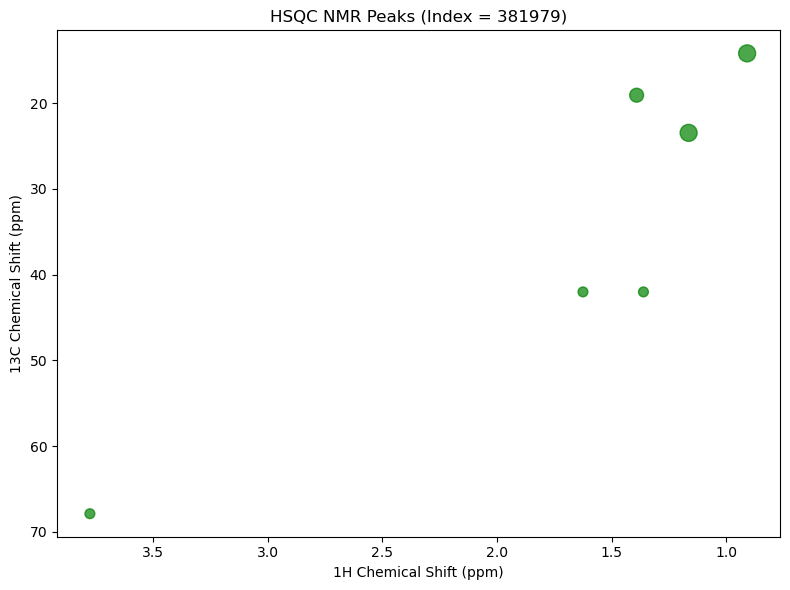

In [ ]:
# -- 绘制 hsqc_nmr 谱图(仅peak)

import pandas as pd
import matplotlib.pyplot as plt
import os
import ast


df = pd.read_parquet(file_path, columns=["smiles", "hsqc_nmr_peaks"])

fout = open(output_path+'hsqc_peaks.jsonl','w')
for idx, row in df.iterrows():
    row = df.iloc[idx]       
    peaks_data = row["hsqc_nmr_peaks"]
    smiles = row["smiles"]    
    if isinstance(peaks_data, str):
        try:
            peaks_data = ast.literal_eval(peaks_data)
        except Exception:
            peaks_data = []    
    proton_shifts = []
    carbon_shifts = []
    intensities = []
    result = []
    for item in peaks_data:
        if isinstance(item, dict):
            carbon_max = item.get("13C_max")
            carbon_min = item.get("13C_min")
            proton_max = item.get("1H_max")
            proton_min = item.get("1H_min")
            nH = item.get("nH")
            if proton_max is not None and proton_min is not None and carbon_max is not None and carbon_min is not None and nH is not None:
                proton_shifts.append((proton_max + proton_min) / 2)  # 使用1H最大值和最小值的平均值作为化学位移
                carbon_shifts.append((carbon_max + carbon_min) / 2)  # 使用13C最大值和最小值的平均值作为化学位移
                intensities.append(nH if nH is not None else 1)  # 使用 nH 作为峰的强度
                tmp_data = {}
                tmp_data['position'] = (proton_max + proton_min) / 2
                tmp_data['c'] = (carbon_max + carbon_min) / 2
                tmp_data['intensity'] = nH if nH is not None else 1
                result.append(tmp_data)
    if not proton_shifts or not carbon_shifts:
        continue
    peaks_info = {'1h_shifts':proton_shifts,'13c_shifts':carbon_shifts,'intensity':intensities}
    fout.write(json.dumps({'smiles':smiles,'peaks':result,'idx':str(idx)})+'\n')
fout.close()

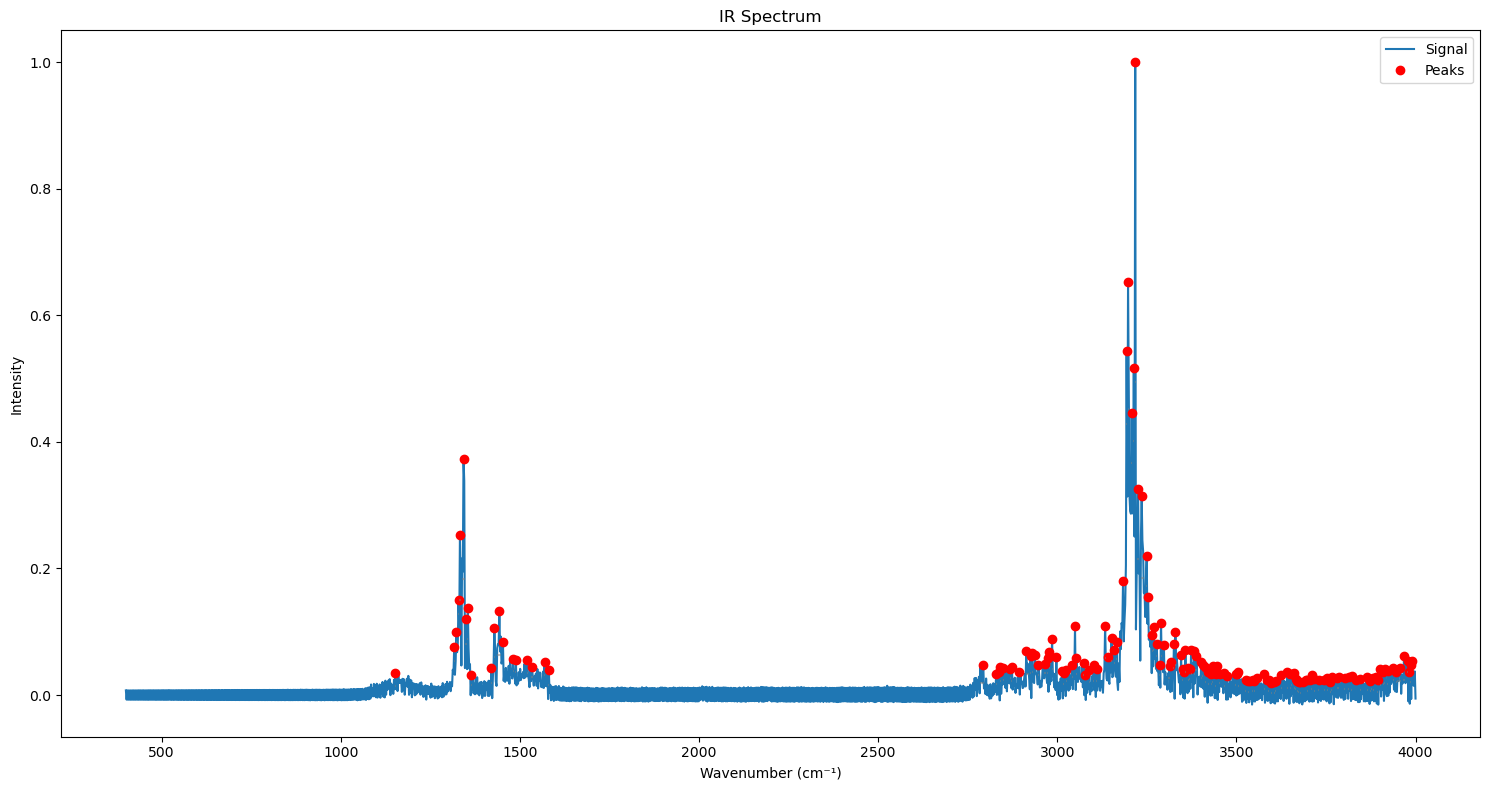

In [ ]:
# -- 绘制 ir 谱图

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
import os
import json

df = pd.read_parquet(file_path, columns=["smiles", "ir_spectra"])

fout = open(output_path+'multi_ir_new.jsonl','w')
for idx, row in df.iterrows():
    row = df.iloc[idx]    
    intensity  = row["ir_spectra"]
    smiles = row["smiles"]    
    if intensity is None or len(intensity) == 0:
        continue
    intensity = np.array(intensity)
    if np.all(intensity == 0):
        continue
    n_points = len(intensity)
    wavenumbers = np.linspace(4000, 400, n_points)

    peaks_info=extract_peaks_info_width(wavenumbers,intensity,plot=False, prominence=0.03,title='IR Spectrum',xl='Wavenumber (cm⁻¹)',yl='Intensity')
    fout.write(json.dumps({'molecule_number':smiles,'peaks':peaks_info,'idx':str(idx)})+'\n')

fout.close()


In [12]:
# multimodal prompts v2 (输入允许不全[1:])
import random
import pandas as pd
import os
import json
import re
import numpy as np

def generate_spec_str(spec_data, type='cnmr', desctribe=False):   ##目前没加width
    spec_str = ''
    x_list = []
    x1_list = []
    y_list = []
    for spec in spec_data:
        y = spec['intensity']
        if y < 0.1:  continue
        x = spec['position']
        x_list.append(str(round(x,2)))
        if type == 'hsqc':
            x1 = spec['c']
            x1_list.append(str(round(x1,2)))
        y_list.append(str(round(y,2)))
    if type == 'cnmr':
        spec_data = {'C-shifts':','.join(x_list),'Intensities':','.join(y_list)}
        spec_str = 'Carbon-13 Nuclear Magnetic Resonance '+json.dumps(spec_data)
        if desctribe:
            spec_str += ', the spectra data includes the Chemical Shift positions in ppm as C-shifts and corresponding intensities as Intensities'
    if type == 'hnmr':
        spec_data = {'H-shifts':','.join(x_list),'Intensities':','.join(y_list)}
        spec_str = 'Proton Nuclear Magnetic Resonance '+json.dumps(spec_data)
        if desctribe:
            spec_str += ', the spectra data includes the Chemical Shift positions in ppm as H-shifts and corresponding intensities as Intensities'
    if type == 'hsqc':
        spec_data = {'H-shifts':','.join(x_list),'C-shifts':','.join(x1_list),'Intensities':','.join(y_list)}
        spec_str = 'Heteronuclear Single Quantum Coherence '+json.dumps(spec_data)
        if desctribe:
            spec_str += ', the spectra data includes the Chemical Shift positions in ppm as C-shifts,H-shifts and corresponding intensities as Intensities'
    if type == 'ir':
        spec_data = {'Wavenumbers':','.join(x_list),'Intensities':','.join(y_list)}
        spec_str = 'Infrared Spectrum '+json.dumps(spec_data)
        if desctribe:
            spec_str += ', the spectra data includes the wavenumber positions in reciprocal centimeters as Wavenumbers and corresponding intensities as Intensities'
    if type == 'msms':
        spec_data = {'mzs':','.join(x_list),'Intensities':','.join(y_list)}
        spec_str = 'Mass spectrum data '+json.dumps(spec_data)
        if desctribe:
            spec_str += ', the spectra data includes mass-to-charge ratios (m/z) as mzs and their corresponding relative intensities as Intensities.'
    return spec_str


# 单张谱
def generate_single_prompt(SMILES, spec_data, type='ir'):
    system = "You are a chemist. Given the description of spectras extracted from a compound, you are skilled at analyzing this spectra to infer whether the compound contains certain fragments or functional groups, and then combining information to deduce which compound this spectra correspond to, and accurately provide the SMILES of the compound."
    spec_str = generate_spec_str(spec_data,type,True)
    prompt = "Given {spec_str}. Based on the information provided, predict which compound the spectra correspond to and give the SMILES of that compound. Please answer strictly in the format ##SMILES: .".format(spec_str=spec_str)
    response = '##SMILES: ' + SMILES
    prompt_data = {
        'system' : system,
        'response' : response,
        'prompt' : prompt
    }  
    return prompt_data

# 所有谱
def generate_all_prompt(SMILES, spec_lists):
    system = "You are a chemist. Given the description of spectras extracted from a compound, you are skilled at analyzing these spectra to infer whether the compound contains certain fragments or functional groups, and then combining those information to deduce which compound these spectra correspond to, and accurately provide the SMILES of the compound."
    prompt = "Given multiple spectra, they are " + ', '.join(spec_lists)+'. All of these spectra are determined by the same compound,  with the wavenumber postions in reciprocal centimeters as Wavenumbers, the energy postions in eV as Energies and corresponding intensities as Intensities. Based on the information provided by these spectra, predict which compound the spectra correspond to and give the SMILES of that compound. Please answer strictly in the format ##SMILES: .'
    response = '##SMILES: ' + SMILES
    prompt_data = {
        'system' : system,
        'response' : response,
        'prompt' : prompt
    }  
    return prompt_data

def load_peaks(file_path):
    mol_peaks = {}
    with open(file_path) as fin:
        for line in fin:
            try:
                tmp_data = json.loads(line.strip())
                mol_peaks[tmp_data["smiles"]] = tmp_data["peaks"]
            except:
                continue
            # break
    return mol_peaks

def to_str_or_none(x):
    if pd.isna(x):
        return None
    if isinstance(x, (float, np.floating)):
        if x.is_integer():
            x = int(x)
    if isinstance(x, (int, np.integer)):
        return str(x)
    return str(x)

cnr_path = '../data/raw_data/multimodal-spectroscopic-dataset/cnr_peaks.jsonl'
hnr_path = '../data/raw_data/multimodal-spectroscopic-dataset/hnr_peaks.jsonl'    
hsqc_path = '../data/raw_data/multimodal-spectroscopic-dataset/hsqc_peaks.jsonl'
ir_path = '../data/raw_data/multimodal-spectroscopic-dataset/ir_peaks.jsonl'
msms_path = '../data/raw_data/multimodal-spectroscopic-dataset/multi_msms_peaks.jsonl'
data_dict = {}
data_dict['cnr'] = load_peaks(cnr_path)
# data_dict['hnr'] = load_peaks(hnr_path)
# data_dict['hsqc'] = load_peaks(hsqc_path)
# data_dict['ir'] = load_peaks(ir_path)
# data_dict['msms'] = load_peaks(msms_path)

file_path = "../data/raw_data/smiles2datasetIdx_few.csv"
df = pd.read_csv(file_path,usecols=['SMILES','multimodal_spectroscopic_dataset_Idx'])

smiles_path = "../data/raw_data/split_total_test_few.smi"
smiles_list =[]
cnt = 0
mode = 'train'
with open(smiles_path) as fin:
    for line in fin:
        tmp_smiles = line.strip()
        smiles_list.append(tmp_smiles)
data_type = ["1"] #['all','1']
path_head = "../data/MultiSpecDataset"
date = '20250922'
def write_msd_result(data,idx=None,path='msd.jsonl',max_len=1280):
    if len(data['prompt']) > max_len:
        cnt += 1
        return
    with open(path,'a') as fout:
        if idx:
            data['idx'] = idx
        fout.write(json.dumps(data)+'\n')
train_flag = True
if mode != 'train':
    train_flag = False
cnt = 0
for index, row in df.iterrows():
    if cnt > 100: break
    smiles = row['SMILES']
    if train_flag and smiles in smiles_list:   continue
    if not train_flag and smiles not in smiles_list:    continue
    msd_idxs  = to_str_or_none(row.get('multimodal_spectroscopic_dataset_Idx'))
    if msd_idxs:
        for msd_idx in msd_idxs.split('|'):
            msd_idx = str(msd_idx)
            spec_list = []
            for key in data_dict:
                if msd_idx in data_dict[key] and msd_idx not in other_dict:
                    cnt += 1
                    single_prompt = generate_single_prompt(smiles,data_dict[key][msd_idx],key)
                    if '1' in data_type:
                        write_msd_result(single_prompt,path='_'.join([path_head,key,mode,date])+'.jsonl')
                    cur_spec = generate_spec_str(data_dict[key][msd_idxs],key)
                    spec_list.append(cur_spec)
            if 'all' in data_type and len(spec_list) > 0:
                all_prompt = generate_all_prompt(smiles,spec_list)
                write_msd_result(all_prompt,path='_'.join([path_head,'nmr',mode,date])+'.jsonl')

print(cnt)

/tmp/ipykernel_713060/3828048032.py:111: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path,usecols=['SMILES','multimodal_spectroscopic_dataset_Idx'])


0
